# Facebook Engagement Analysis – Building Linear Regression Model

Author: Nick Peril  
Project: TKH Phase I Portfolio

### Objective:
To create a linear regression model to predict Facebook posts' total interactions.

### Importing Libraries:

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

### Loading cleaned dataset:

In [2]:
df = pd.read_csv('/Users/saadult/facebook-metrics/data/02_clean/facebook_clean.csv')

df.head()

,page_total_likes,category,post_month,post_hour,paid,total_interactions_log,type_Photo,type_Status,type_Video,post_weekday_2,post_weekday_3,post_weekday_4,post_weekday_5,post_weekday_6,post_weekday_7,time_of_day_morning,time_of_day_afternoon,time_of_day_evening
0,139441,2,12,3,0.0,4.615121,1,0,0,0,0,1,0,0,0,0,0,0
1,139441,2,12,10,0.0,5.105945,0,1,0,0,1,0,0,0,0,1,0,0
2,139441,3,12,3,0.0,4.394449,1,0,0,0,1,0,0,0,0,0,0,0
3,139441,2,12,10,1.0,7.483244,1,0,0,1,0,0,0,0,0,1,0,0
4,139441,2,12,3,0.0,5.976351,1,0,0,1,0,0,0,0,0,0,0,0


### Defining features and target:

In [3]:
X = df.drop(columns=['total_interactions_log'])
y = df['total_interactions_log']

### Train/Test split:

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2,
    random_state=42
)

print(f"Train: {X_train.shape[0]} rows | Test: {X_test.shape[0]} rows")

Train: 399 rows | Test: 100 rows


### Feature Scaling:

In [5]:
df.columns

Index(['page_total_likes', 'category', 'post_month', 'post_hour', 'paid',
       'total_interactions_log', 'type_Photo', 'type_Status', 'type_Video',
       'post_weekday_2', 'post_weekday_3', 'post_weekday_4', 'post_weekday_5',
       'post_weekday_6', 'post_weekday_7', 'time_of_day_morning',
       'time_of_day_afternoon', 'time_of_day_evening'],
      dtype='object')

In [7]:
continuous_features = ['page_total_likes', 'category', 'post_month', 'post_hour']
dummy_features = ['paid', 'type_Photo', 'type_Status', 'type_Video', 'post_weekday_2', 'post_weekday_3', 'post_weekday_4', 'post_weekday_5', 'post_weekday_6', 'post_weekday_7', 'time_of_day_morning','time_of_day_afternoon', 'time_of_day_evening']

scaler = StandardScaler()

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

scaler.fit(X_train[continuous_features])

X_train_scaled[continuous_features] = scaler.transform(X_train[continuous_features])
X_test_scaled[continuous_features] = scaler.transform(X_test[continuous_features])

X_train_scaled.head()

,page_total_likes,category,post_month,post_hour,paid,type_Photo,type_Status,type_Video,post_weekday_2,post_weekday_3,post_weekday_4,post_weekday_5,post_weekday_6,post_weekday_7,time_of_day_morning,time_of_day_afternoon,time_of_day_evening
56,0.941769,-1.049043,1.230644,0.709827,0.0,1,0,0,0,0,0,1,0,0,1,0,0
227,0.522492,-1.049043,-0.011676,0.479940,1.0,1,0,0,0,0,1,0,0,0,1,0,0
280,0.180579,0.146866,-0.322256,0.939715,0.0,1,0,0,0,0,0,0,0,0,0,1,0
486,-2.383354,1.342775,-1.875155,0.939715,0.0,1,0,0,0,0,0,0,0,0,0,1,0
220,0.536974,0.146866,0.298904,-0.899384,0.0,1,0,0,0,0,0,0,0,0,0,0,0


### Building my model

In [8]:
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)

print("Linear Regression metrics")
print(f"  R²:   {r2_score(y_test, y_pred_lr):.4f}")
print(f"  MSE: {(mean_squared_error(y_test, y_pred_lr)):.4f}")
print(f"  RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_lr)):.4f}")

Linear Regression metrics
  R²:   0.0481
  MSE: 1.1484
  RMSE: 1.0716


R² of 0.0481 means model explains about 4.8% of the variation in post engagement. The features in the model (post type, time, paid, etc.) explains only a small part of why posts get interactions. The remaining 95% is influenced by other factors which could be things like content quality, trends, and audience interests.

MSE of 1.1484 measures how far predictions are from the true values. On average, the squared difference between predicted and actual engagement is about 1.15.

RMSE of 1.0716 is the average prediction error. My model;s prediction is off by about 1.07 units on average or about 1 log unit away from the real total interactions values.

In [15]:
ridge = Ridge(alpha=0.3)
ridge.fit(X_train_scaled, y_train)

y_pred_ridge = ridge.predict(X_test_scaled)

print("RIDGE REGRESSION (alpha=0.3)")
print(f"  R²:   {r2_score(y_test, y_pred_ridge):.4f}")
print(f"  MSE: {(mean_squared_error(y_test, y_pred_ridge)):.4f}")
print(f"  RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_ridge)):.4f}")

RIDGE REGRESSION (alpha=0.3)
  R²:   0.0501
  MSE: 1.1460
  RMSE: 1.0705


Ridge regression explains about 5.0% of the variation, slightly better than the 4.8% from linear regression. Ridge has slightly smaller error (MSE = 1.1460), meaning its predictions are a bit closer to the real values. On average, Ridge predictions are off by about 1.07 units, which is slightly better than linear regression.

In [16]:
lasso = Lasso(alpha=0.1) 
lasso.fit(X_train_scaled, y_train)

y_pred_lasso = lasso.predict(X_test_scaled)

print("LASSO REGRESSION (alpha=0.1)")
print(f"  R²:   {r2_score(y_test, y_pred_lasso):.4f}")
print(f"  MSE: {(mean_squared_error(y_test, y_pred_lasso)):.4f}")
print(f"  RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_lasso)):.4f}")

LASSO REGRESSION (alpha=0.1)
  R²:   0.0268
  MSE: 1.1741
  RMSE: 1.0836


Since lasso regression uses a stronger penalty and can shrink some coefficients all the way to zero, it could totally remove some features that are not useful. In this case I used an alpha of 1 and R² gave an output of 0.0268, this is lower than the other models. So Lasso performed worse. MSE of 1.1741 is the highest error among the three models, meaning predictions are less accurate. Laslty, RMSE of 1.0836 means predictions are off by about 1.08 units on average, slightly worse than the other models.

In [17]:
lasso_coefs = pd.Series(lasso.coef_, index=X_train.columns)
lasso_coefs

page_total_likes         0.000000
category                 0.343093
post_month               0.000000
post_hour               -0.000000
paid                     0.000000
type_Photo              -0.000000
type_Status              0.000000
type_Video               0.000000
post_weekday_2           0.000000
post_weekday_3           0.000000
post_weekday_4           0.000000
post_weekday_5           0.000000
post_weekday_6          -0.000000
post_weekday_7          -0.000000
time_of_day_morning     -0.000000
time_of_day_afternoon   -0.000000
time_of_day_evening     -0.000000
dtype: float64

Lasso decided to remove almost all of the features and only retain category, which earlier saw a moderate positive relationship with total interactions in correlation heatmap. All other features where deemed not useful to predict the target.

### Overfitting diagnostic:

In [18]:
print("Train R²:")
print(f"  Linear Regression: {r2_score(y_train, lr.predict(X_train_scaled)):.4f}")
print(f"  Ridge:             {r2_score(y_train, ridge.predict(X_train_scaled)):.4f}")
print(f"  Lasso:             {r2_score(y_train, lasso.predict(X_train_scaled)):.4f}")

print("\nTest R²:")
print(f"  Linear Regression: {r2_score(y_test, y_pred_lr):.4f}")
print(f"  Ridge:             {r2_score(y_test, y_pred_ridge):.4f}")
print(f"  Lasso:             {r2_score(y_test, y_pred_lasso):.4f}")

Train R²:
  Linear Regression: 0.2175
  Ridge:             0.2172
  Lasso:             0.1234

Test R²:
  Linear Regression: 0.0481
  Ridge:             0.0501
  Lasso:             0.0268


Linear and Ridge models explain about 21% of engagement patterns in the training data while Lasso explains about 12%. So the mdoels learned some patterns, but not very strong.

When the models were tested on new data, they only explained about 3–5% of engagement behavior. The models perform much better on training data than on new data.

Looking at the results, Ridge Regression performed slightly better than the others. However, the improvement is very small. This indicates that the available features do not strongly explain engagement, and other factors not included in the dataset likely play a larger role.

### Visualizing predictions:

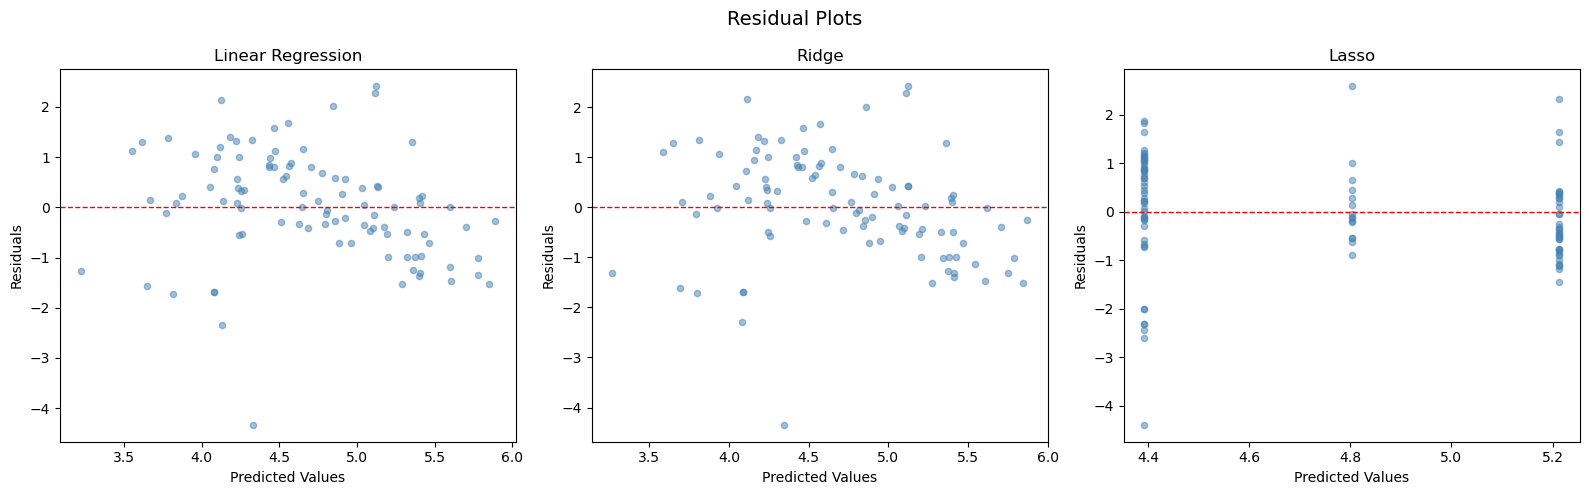

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

models = {
    'Linear Regression': y_pred_lr,
    'Ridge': y_pred_ridge,
    'Lasso': y_pred_lasso
}

for ax, (name, y_pred) in zip(axes, models.items()):
    residuals = y_test - y_pred
    ax.scatter(y_pred, residuals, alpha=0.5, color='steelblue', s=20)
    ax.axhline(y=0, color='red', linestyle='--', linewidth=1)
    ax.set_xlabel('Predicted Values')
    ax.set_ylabel('Residuals')
    ax.set_title(name)

plt.suptitle('Residual Plots', fontsize=14)
plt.tight_layout()
plt.show()

The Linear Regression Plot saw points are scattered above and below the red line, meaning there is no strong pattern. The model sometimes predicts too high and sometimes too low. There are some points far from the line, meaning some posts were hard to predict.

The Ridge Regression Plot looks almost the same as Linear Regression. This means it behaves ery similarly to linear regression.

The Lasso Regression Plot looks very different, we can see vertical lines of points. This means Lasso predicted very similar values for many posts. Or in simple words, the model simplified too much and gave similar predictions for different posts. This is why Lasso had the worse accuracy, it removed too many useful features.

Overall, the errors appear randomly scattered, but the large spread of points suggests that the models struggle to accurately predict post engagement.

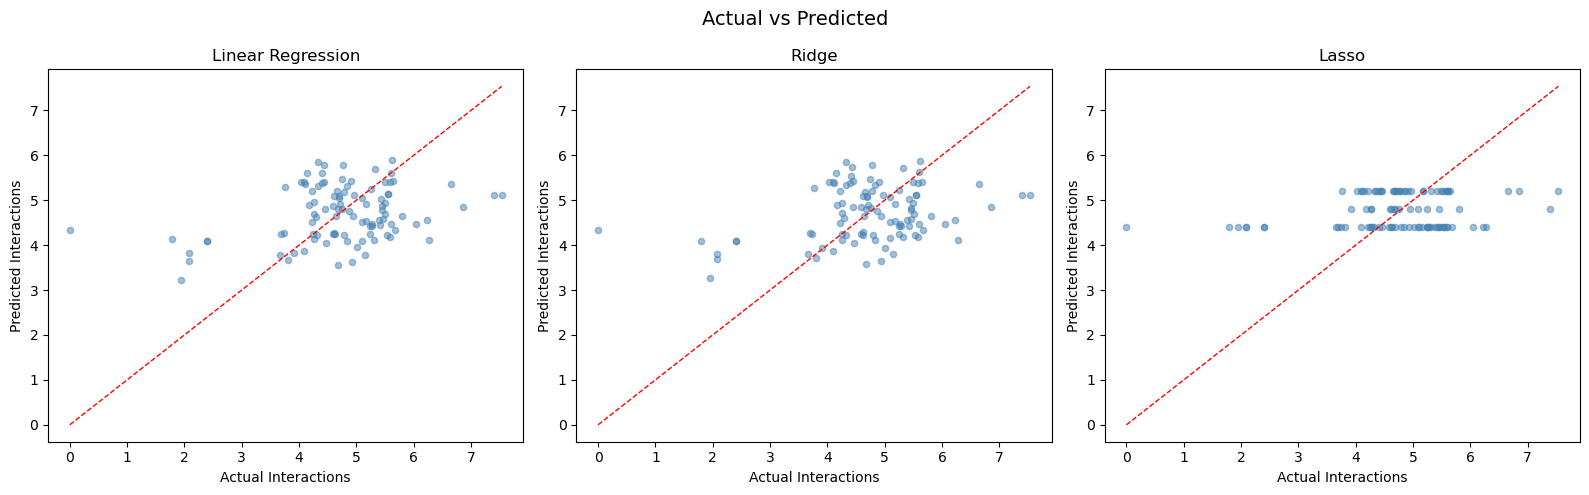

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, (name, y_pred) in zip(axes, models.items()):
    ax.scatter(y_test, y_pred, alpha=0.5, color='steelblue', s=20)
    ax.plot([y_test.min(), y_test.max()],
            [y_test.min(), y_test.max()],
            color='red', linestyle='--', linewidth=1)
    ax.set_xlabel('Actual Interactions')
    ax.set_ylabel('Predicted Interactions')
    ax.set_title(name)

plt.suptitle('Actual vs Predicted', fontsize=14)
plt.tight_layout()
plt.show()

In Linear Regression Plot, the dots are near the red line, but many are also scattered around it. This means the model sometimes predicts engagement correctly, but often it is off.

Ridge Regression Plot looks almost identical to Linear Regression. This means it made very similar predictions to linear regression.

Lasso Regression Plot looks different and we can see horizontal lines of dots. The model simplified too much and produced fewer unique predictions.

Overall, the models capture some patterns but still have noticeable prediction errors.

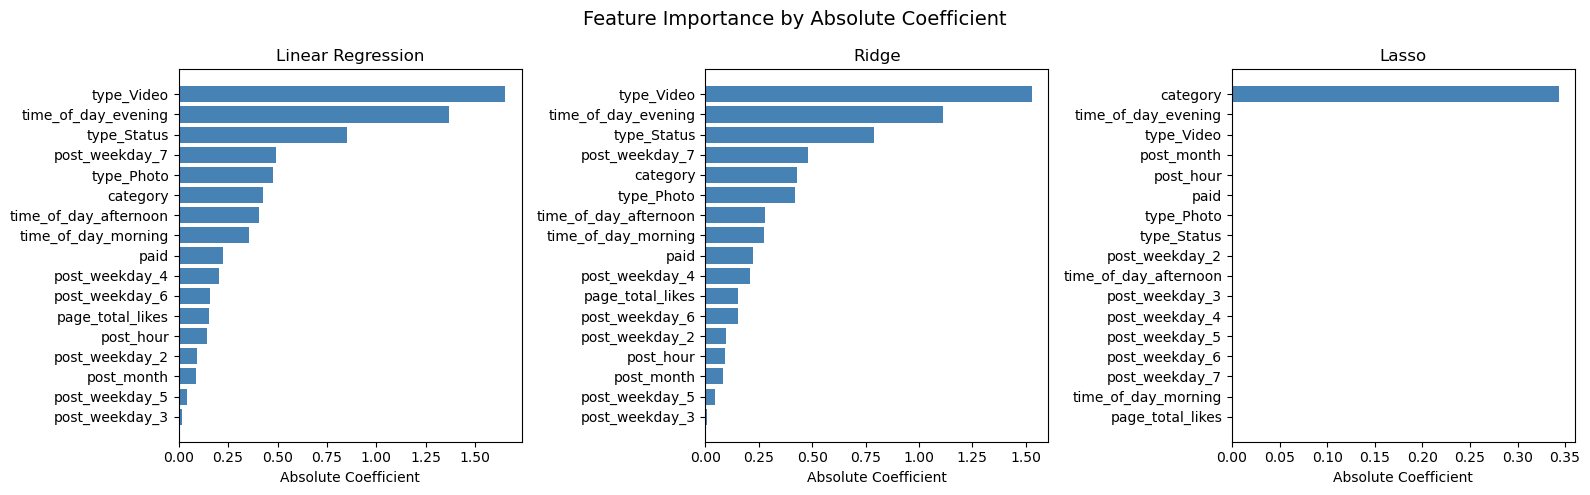

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

coef_data = {
    'Linear Regression': lr.coef_,
    'Ridge': ridge.coef_,
    'Lasso': lasso.coef_
}

for ax, (name, coefs) in zip(axes, coef_data.items()):
    abs_coefs = pd.Series(np.abs(coefs), index=X_train.columns).sort_values(ascending=True)
    ax.barh(abs_coefs.index, abs_coefs.values, color='steelblue')
    ax.set_xlabel('Absolute Coefficient')
    ax.set_title(name)

plt.suptitle('Feature Importance by Absolute Coefficient', fontsize=14)
plt.tight_layout()
plt.show()

These charts show which features had the biggest influence on the models’ predictions. In both the Linear Regression and Ridge models, video posts and posting in the evening seem to have the strongest impact on engagement. Post type (video or status) and some timing factors like weekday and time of day also appear to matter a bit. Other features like page total likes, post hour, and post month have much smaller effects, meaning they didn’t change the predictions very much.

The Lasso model looks very different because it removed most of the features and kept only category as the main factor. This happens because Lasso tries to simplify the model by dropping features that it thinks are not very useful. 

Overall, the results suggest that what type of post it is and when it is posted may influence engagement more than things like page size or exact posting hour, but none of the features are extremely strong predictors on their own.